# Clustering optimisers

The optimisers we have met so far (`MeanRisk`, `RiskBudgeting`,
`NearOptimalCentering`) all solve a single global problem over every asset at once.
*Clustering optimisers* take a different route: they first group the assets into a hierarchy
from their dependency structure (a dendrogram), then allocate **within and across** those
groups. Because they never invert the full covariance matrix and need no expected returns,
they are robust to estimation error and require no numerical solver for variance-based risk.

`PortfolioOptimisers` ships three members of this family:

  - `HierarchicalRiskParity` (HRP) — recursive bisection of the dendrogram, splitting
    risk between each pair of sub-clusters.
  - `HierarchicalEqualRiskContribution` (HERC) — equalises risk contributions both
    *within* each cluster (inner) and *across* clusters (outer), with independent risk
    measures and scalarisers for each level.
  - `SchurComplementHierarchicalRiskParity` (SCHRP) — augments each sub-cluster's
    covariance with a Schur-complement correction, interpolating between HRP (`gamma = 0`)
    and a Markowitz-like allocation as `gamma → 1`.

> **When to reach for this**
>
> Reach for a clustering optimiser when you want the allocation driven by the *correlation
> structure* of the assets rather than by a return forecast — to diversify across genuine
> groupings, to stay robust when the covariance matrix is noisy or near-singular, or simply
> to avoid running a solver. Use HRP for the classic robust baseline, HERC when you want
> explicit control of the risk split within vs across clusters, and SCHRP when you want to
> dial in some of mean-variance's efficiency without giving up the hierarchy's stability.
> If you want an explicit return/risk trade-off instead, use `MeanRisk`.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
tsfmt = (v, i, j) -> begin
    if j == 1
        return Date(v)
    else
        return v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other optimiser examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
pretty_table(X[(end - 5):end]; formatters = [tsfmt])

# Compute the returns
rd = prices_to_returns(X)

┌────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────
│  timestamp │    AAPL │     AMD │     BAC │     BBY │     CVX │      GE │     ⋯
│       Date │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Flo ⋯
├────────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼──────
│ 2022-12-20 │ 131.916 │   65.05 │  31.729 │  77.371 │ 169.497 │  62.604 │ 310 ⋯
│ 2022-12-21 │ 135.057 │   67.68 │  32.212 │  78.729 │  171.49 │   64.67 │ 314 ⋯
│ 2022-12-22 │ 131.846 │   63.86 │  31.927 │  78.563 │ 168.918 │  63.727 │ 311 ⋯
│ 2022-12-23 │ 131.477 │   64.52 │  32.005 │  79.432 │  174.14 │  63.742 │ 314 ⋯
│ 2022-12-27 │ 129.652 │   63.27 │  32.065 │   79.93 │ 176.329 │  64.561 │ 314 ⋯
│ 2022-12-28 │ 125.674 │   62.57 │  32.301 │  78.279 │ 173.728 │  63.883 │  31 ⋯
└────────────┴─────────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────
                                                              14 columns omitted


ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Prior and clustering

Clustering optimisers need two precomputable ingredients: a prior (for the covariance) and a
clustering of the assets. We compute both once and reuse them across every optimiser so the
comparison is apples-to-apples — only the allocation algorithm changes.

We cluster with the Direct Bubble Hierarchy Tree (`DBHT`) algorithm, which builds the
hierarchy from the correlation-derived distance matrix.

In [3]:
pr = prior(EmpiricalPrior(), rd)
clr = clusterise(ClustersEstimator(; alg = DBHT()), pr.X)

Clusters
  res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
    S ┼ 20×20 Matrix{Float64}
    D ┼ 20×20 Matrix{Float64}
    P ┼ nothing
    k ┴ Int64: 4


We can inspect the structure the optimisers will act on: the dendrogram and the reordered
correlation heatmap with the detected cluster boundaries.

Hierarchical clustering dendrogram.

In [4]:
using StatsPlots, GraphRecipes

Reordered correlation heatmap with cluster boundary boxes.

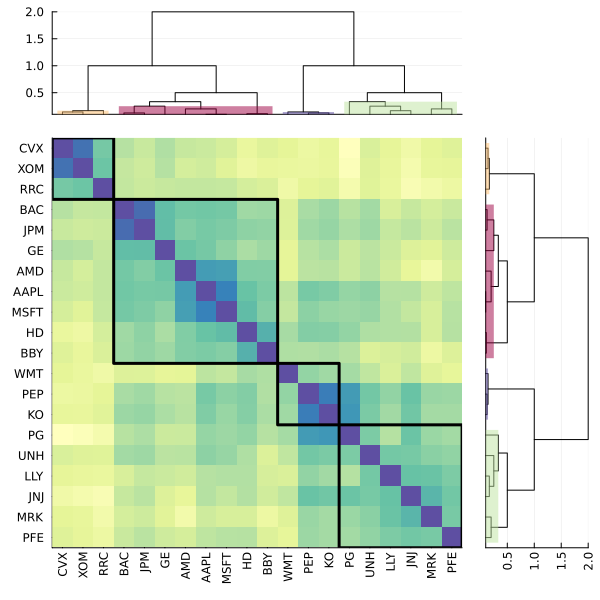

In [5]:
plot_dendrogram(clr, rd.nx)
plot_clusters(clr, rd.nx)

## 3. Hierarchical risk parity (HRP)

HRP recursively bisects the dendrogram and splits the budget between each pair of
sub-clusters in inverse proportion to their risk. We pass the shared prior and clustering
through a `HierarchicalOptimiser`. Variance needs no solver, so none is supplied.

In [6]:
opt = HierarchicalOptimiser(; pe = pr, cle = clr)
res_hrp = optimise(HierarchicalRiskParity(; opt = opt, r = Variance()))

HierarchicalResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      clr ┼ Clusters
          │   res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
          │     S ┼ 20×20 Matrix{Float64}
          │     D ┼ 20×20 Matrix{Float64}
          │  

## 4. Hierarchical equal risk contribution (HERC)

HERC equalises risk contributions within each cluster (the inner problem) and across clusters
(the outer problem). It accepts separate inner/outer risk measures (`ri`, `ro`) and
scalarisers (`scai`, `scao`); here we use `Variance` for both levels.

In [7]:
res_herc = optimise(HierarchicalEqualRiskContribution(; opt = opt, ri = Variance(),
                                                      ro = Variance()))

HierarchicalResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      clr ┼ Clusters
          │   res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333333, 0.5, 1.0, 2.0], [5, 20, 17, 3, 9, 6, 2, 1, 13, 7, 4, 19, 14, 10, 16, 18, 11, 8, 12, 15], :DBHT)
          │     S ┼ 20×20 Matrix{Float64}
          │     D ┼ 20×20 Matrix{Float64}
          │  

## 5. Schur-complement HRP (SCHRP)

SCHRP corrects each sub-cluster's covariance with a Schur complement of the off-diagonal
(inter-cluster) block, controlled by `gamma`. At `gamma = 0` it reduces to HRP; as `gamma`
grows it absorbs more of the cross-cluster information, moving toward a Markowitz-like
allocation while keeping the hierarchical structure. We sweep three values to make the
interpolation visible.

In [8]:
res_schur0 = optimise(SchurComplementHierarchicalRiskParity(; opt = opt,
                                                            params = SchurComplementParams(;
                                                                                           r = Variance(),
                                                                                           gamma = 0.0)))
res_schur5 = optimise(SchurComplementHierarchicalRiskParity(; opt = opt,
                                                            params = SchurComplementParams(;
                                                                                           r = Variance(),
                                                                                           gamma = 0.5)))
res_schur9 = optimise(SchurComplementHierarchicalRiskParity(; opt = opt,
                                                            params = SchurComplementParams(;
                                                                                           r = Variance(),
                                                                                           gamma = 0.9)))

SchurComplementHierarchicalRiskParityResult
       oe ┼ DataType: DataType
       pr ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
       wb ┼ WeightBounds
          │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
          │   ub ┴ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
      clr ┼ Clusters
          │   res ┼ Clustering.Hclust{Float64}([-1 -13; -7 -4; … ; 12 17; 10 18], [0.1, 0.1111111111111111, 0.125, 0.14285714285714285, 0.16666666666666666, 0.2, 0.25, 0.3333333333333

## 6. Comparing the allocations

With everything sharing one prior and one clustering, the weight differences come purely from
the allocation rule. Note how SCHRP at `gamma = 0` matches HRP, and drifts away from it as
`gamma` increases.

In [9]:
pretty_table(DataFrame(; :assets => rd.nx, :HRP => res_hrp.w, :HERC => res_herc.w,
                       Symbol("SCHRP γ=0") => res_schur0.w,
                       Symbol("SCHRP γ=0.5") => res_schur5.w,
                       Symbol("SCHRP γ=0.9") => res_schur9.w); formatters = [resfmt])

┌────────┬──────────┬──────────┬───────────┬─────────────┬─────────────┐
│ assets │      HRP │     HERC │ SCHRP γ=0 │ SCHRP γ=0.5 │ SCHRP γ=0.9 │
│ String │  Float64 │  Float64 │   Float64 │     Float64 │     Float64 │
├────────┼──────────┼──────────┼───────────┼─────────────┼─────────────┤
│   AAPL │   3.26 % │  1.847 % │    3.26 % │     3.257 % │     3.257 % │
│    AMD │  1.263 % │  0.627 % │   1.263 % │     1.285 % │     1.285 % │
│    BAC │  3.356 % │  2.221 % │   3.356 % │     3.206 % │     3.207 % │
│    BBY │  2.871 % │  1.138 % │   2.871 % │     2.912 % │     2.912 % │
│    CVX │  3.937 % │  4.525 % │   3.937 % │     3.915 % │     3.915 % │
│     GE │  3.879 % │  1.924 % │   3.879 % │     3.769 % │     3.769 % │
│     HD │  2.605 % │  2.386 % │   2.605 % │     2.606 % │     2.606 % │
│    JNJ │ 13.136 % │ 10.746 % │  13.136 % │    13.011 % │    13.011 % │
│    JPM │  3.965 % │  2.623 % │   3.965 % │     3.812 % │     3.812 % │
│     KO │  6.299 % │  13.86 % │   6.299 % │      6

The composition plot shows the same story visually across the five allocations.

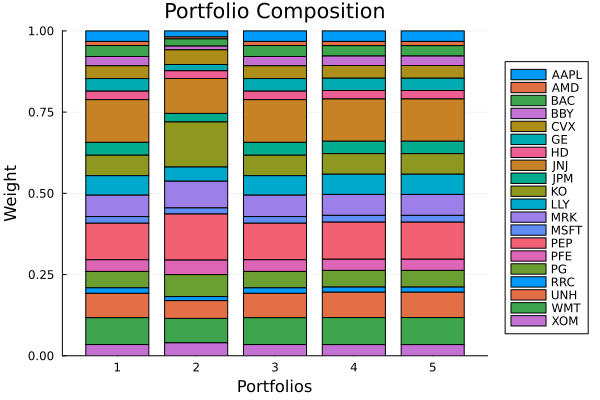

In [10]:
plot_stacked_bar_composition([res_hrp, res_herc, res_schur0, res_schur5, res_schur9], rd)

Finally, the per-asset variance risk contributions for the HRP portfolio confirm that risk —
not capital — is what the hierarchy spreads out. The risk measure needs its covariance
populated from the prior first, which is what `factory` does.

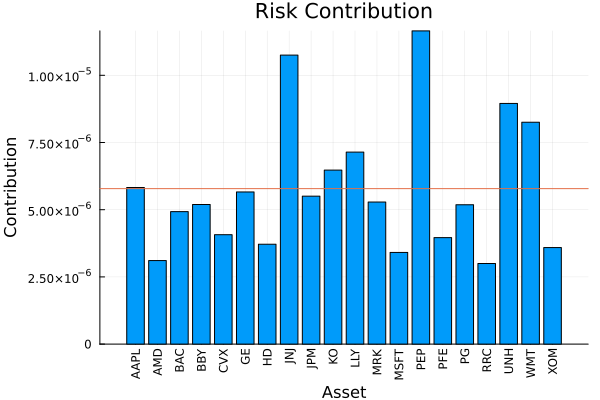

In [11]:
rv = factory(Variance(), pr)
plot_risk_contribution(rv, res_hrp, rd)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*